# 20. 생성기 표현 시각화

18B의 균형 집합에서 수작업 특징과 MERT 표현을 PCA·UMAP으로 그린다. 표준화와 투영기는 Train에서 맞추고 Test에 적용한다. Silhouette는 분류 성능과 다른 질문에 답하므로 함께 읽는다.

## 0. UMAP 설치

`umap-learn`이 없다면 새 **주피터 코드 셀**에서 한 번만 실행:

```python
%pip install -q umap-learn
```

설치 후 커널을 재시작한다.

In [3]:
# 과거 UMAP 시각화에 필요한 umap-learn을 현재 커널에 설치한다.
%pip install -q umap-learn

Note: you may need to restart the kernel to use updated packages.


## 1. 라이브러리 / 경로

In [4]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

try:
    import umap
except ImportError:
    raise ImportError(
        "umap-learn이 없습니다. 새 주피터 코드 셀에서 "
        "`%pip install -q umap-learn` 실행 후 커널을 재시작하세요."
    )

PROJECT_ROOT = Path("/Users/seungjae/Desktop/SNU/기계학습 & 딥러닝/project")

SEGMENT_PATH = PROJECT_ROOT / "data/metadata/segment_manifest_10s.csv"
FEATURE_PATH = PROJECT_ROOT / "data/processed/features/handcrafted_features_10s.csv"
MERT_PATH = PROJECT_ROOT / "data/processed/mert/mert95m_v2_layers_float16.npy"
STRICT_TRACKS_PATH = (
    PROJECT_ROOT
    / "results/generator_attribution/balanced_controlled/strict_selected_tracks.csv"
)

RESULT_DIR = PROJECT_ROOT / "results/generator_fingerprint_visualization"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MERT_LAYER = 10
RANDOM_STATE = 42

segments = pd.read_csv(SEGMENT_PATH).reset_index(drop=True)
features = pd.read_csv(FEATURE_PATH)
# 배열 캐시를 읽어 저장된 특징과 ID의 순서를 확인한다.
mert_cache = np.load(MERT_PATH, mmap_mode="r")
strict_tracks = pd.read_csv(STRICT_TRACKS_PATH)

print("Segments      :", len(segments))
print("Features      :", len(features))
print("MERT cache    :", mert_cache.shape)
print("Strict tracks :", len(strict_tracks))

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(segments) == 10077
assert len(features) == 10077
assert mert_cache.shape == (10077, 13, 768)
assert len(strict_tracks) == 1428

print("Input QC PASS: True")

Segments      : 10077
Features      : 10077
MERT cache    : (10077, 13, 768)
Strict tracks : 1428
Input QC PASS: True


## 2. Handcrafted strict track representation

In [5]:

segment_meta_cols = set(segments.columns)

extra_meta_cols = {
    "Unnamed: 0",
    "index",
    "cache_index",
    "extraction_success",
    "success",
    "error",
}

feature_cols = [
    c
    for c in features.columns
    if c != "segment_id"
    and c not in segment_meta_cols
    and c not in extra_meta_cols
    and not str(c).startswith("Unnamed:")
    and pd.api.types.is_numeric_dtype(features[c])
]

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(feature_cols) == 266

meta = segments[
    [
        "segment_id",
        "track_sample_id",
        "original_audio",
        "generator",
        "genre",
        "split",
        "label",
    ]
].copy()

merged = meta.merge(
    features[["segment_id"] + feature_cols],
    on="segment_id",
    how="inner",
    validate="one_to_one",
)

selected_ids = set(strict_tracks["track_sample_id"])

strict_seg = merged[merged["track_sample_id"].isin(selected_ids)].copy()

hand_track = strict_seg.groupby("track_sample_id", as_index=False).agg(
    {
        **{
            "original_audio": "first",
            "generator": "first",
            "genre": "first",
            "split": "first",
        },
        **{c: "mean" for c in feature_cols},
    }
)

print("Handcrafted track rows:", len(hand_track))
print("Feature dims:", len(feature_cols))

assert len(hand_track) == 1428
assert not hand_track[feature_cols].isna().any().any()

print("Handcrafted Track QC PASS: True")

Handcrafted track rows: 1428
Feature dims: 266
Handcrafted Track QC PASS: True


## 3. MERT Layer 10 strict track representation

In [6]:

segments = segments.copy()
segments["cache_index"] = np.arange(len(segments))

strict_mert_seg = segments[segments["track_sample_id"].isin(selected_ids)].copy()

mert_rows = []

# 같은 곡의 10초 구간을 묶어 곡 단위 결과를 만든다.
for track_id, group in strict_mert_seg.groupby("track_sample_id"):
    idx = group["cache_index"].to_numpy(dtype=int)

    emb = np.asarray(
        mert_cache[idx, BEST_MERT_LAYER, :],
        dtype=np.float32,
    ).mean(axis=0)

    first = group.iloc[0]

    mert_rows.append(
        {
            "track_sample_id": track_id,
            "original_audio": first["original_audio"],
            "generator": first["generator"],
            "genre": first["genre"],
            "split": first["split"],
            "embedding": emb,
        }
    )

mert_track = pd.DataFrame(mert_rows)

print("MERT track rows:", len(mert_track))
print("MERT dims:", len(mert_track.iloc[0]["embedding"]))
print("Layer:", BEST_MERT_LAYER)

# ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
assert len(mert_track) == 1428
assert len(mert_track.iloc[0]["embedding"]) == 768

print("MERT Track QC PASS: True")

MERT track rows: 1428
MERT dims: 768
Layer: 10
MERT Track QC PASS: True


## 4. Strict balance 재확인

In [7]:

for name, df in [
    ("Handcrafted", hand_track),
    ("MERT", mert_track),
]:
    print("\n", name)

    table = pd.crosstab(
        df["generator"],
        df["split"],
    )

    display(table)

    # ID와 행 수가 틀리면 특징·라벨 대응이 어긋나므로 여기서 확인한다.
    assert table["train"].nunique() == 1
    assert table["val"].nunique() == 1
    assert table["test"].nunique() == 1
    assert int(table["train"].iloc[0]) == 83
    assert int(table["val"].iloc[0]) == 17
    assert int(table["test"].iloc[0]) == 19

print("Strict Balance QC PASS: True")


 Handcrafted


split,test,train,val
generator,,,
acestep,19,83,17
audioldm,19,83,17
brev,19,83,17
diffrhythm,19,83,17
elevenlabs,19,83,17
mubert,19,83,17
musicgen,19,83,17
producer,19,83,17
songgen,19,83,17



 MERT


split,test,train,val
generator,,,
acestep,19,83,17
audioldm,19,83,17
brev,19,83,17
diffrhythm,19,83,17
elevenlabs,19,83,17
mubert,19,83,17
musicgen,19,83,17
producer,19,83,17
songgen,19,83,17


Strict Balance QC PASS: True


## 5. PCA — Train fit / Test transform

In [8]:


def get_representation(name):
    if name == "Handcrafted":
        # 같은 원곡의 표본이 여러 분할에 섞이지 않도록 저장된 split을 그대로 사용한다.
        train = hand_track[hand_track["split"] == "train"].reset_index(drop=True)
        test = hand_track[hand_track["split"] == "test"].reset_index(drop=True)

        X_train = train[feature_cols].to_numpy(dtype=np.float32)
        X_test = test[feature_cols].to_numpy(dtype=np.float32)

    elif name == "MERT":
        train = mert_track[mert_track["split"] == "train"].reset_index(drop=True)
        test = mert_track[mert_track["split"] == "test"].reset_index(drop=True)

        X_train = np.stack(train["embedding"].to_numpy()).astype(np.float32)
        X_test = np.stack(test["embedding"].to_numpy()).astype(np.float32)

    else:
        raise ValueError(name)

    return train, test, X_train, X_test


pca_results = {}

for name in ["Handcrafted", "MERT"]:
    train, test, X_train, X_test = get_representation(name)

    # 특징마다 범위가 달라 표준화한다. 평균·표준편차는 Train에서만 구한다.
    scaler = StandardScaler()

    # Train의 평균·표준편차를 구하고 같은 Train 행을 변환한다.
    X_train_z = scaler.fit_transform(X_train)
    # Validation/Test에는 Train의 표준화 기준만 적용해 정보 누수를 막는다.
    X_test_z = scaler.transform(X_test)

    # PCA는 Train에서 큰 변동 방향을 찾고 Test를 같은 두 축에 투영한다.
    pca = PCA(
        n_components=2,
        random_state=RANDOM_STATE,
    )

    pca.fit(X_train_z)

    # Train에서 맞춘 투영기를 다른 분할에 적용해 같은 좌표계로 비교한다.
    coords = pca.transform(X_test_z)

    pca_results[name] = {
        "train": train,
        "test": test,
        "X_test_z": X_test_z,
        "coords": coords,
        "explained": pca.explained_variance_ratio_,
    }

    print(
        name,
        "explained variance:",
        np.round(pca.explained_variance_ratio_, 4),
        "sum=",
        round(float(pca.explained_variance_ratio_.sum()), 4),
    )

Handcrafted explained variance: [0.2658 0.094 ] sum= 0.3598
MERT explained variance: [0.0949 0.0731] sum= 0.168


## 6. PCA Test visualization

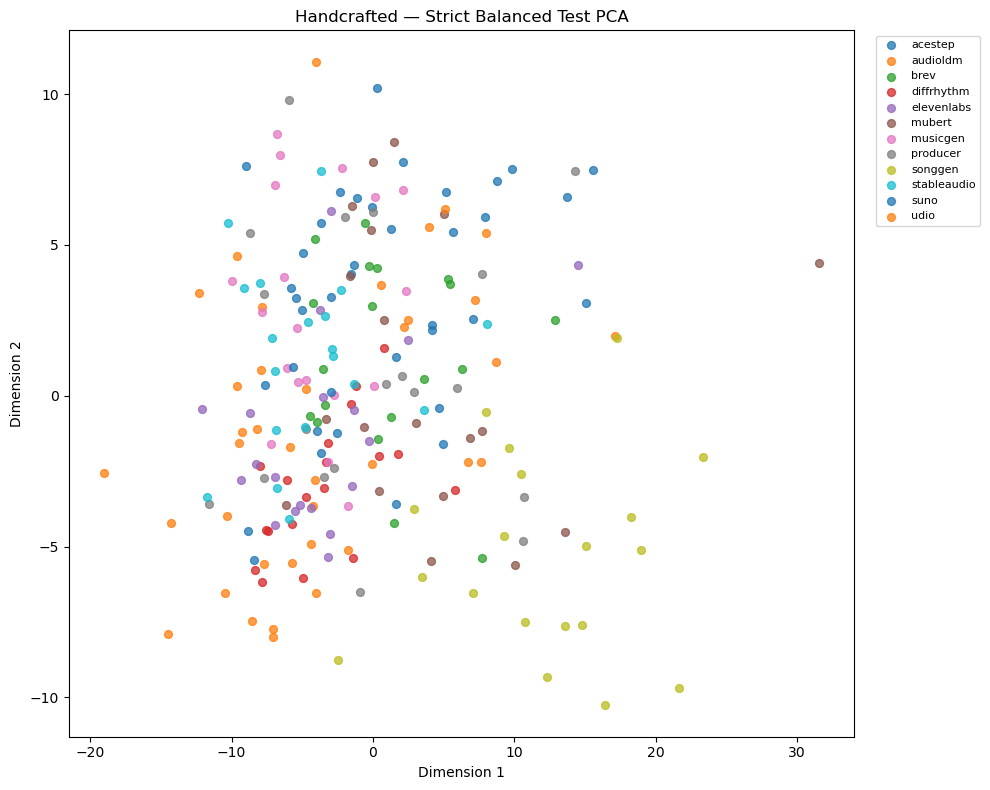

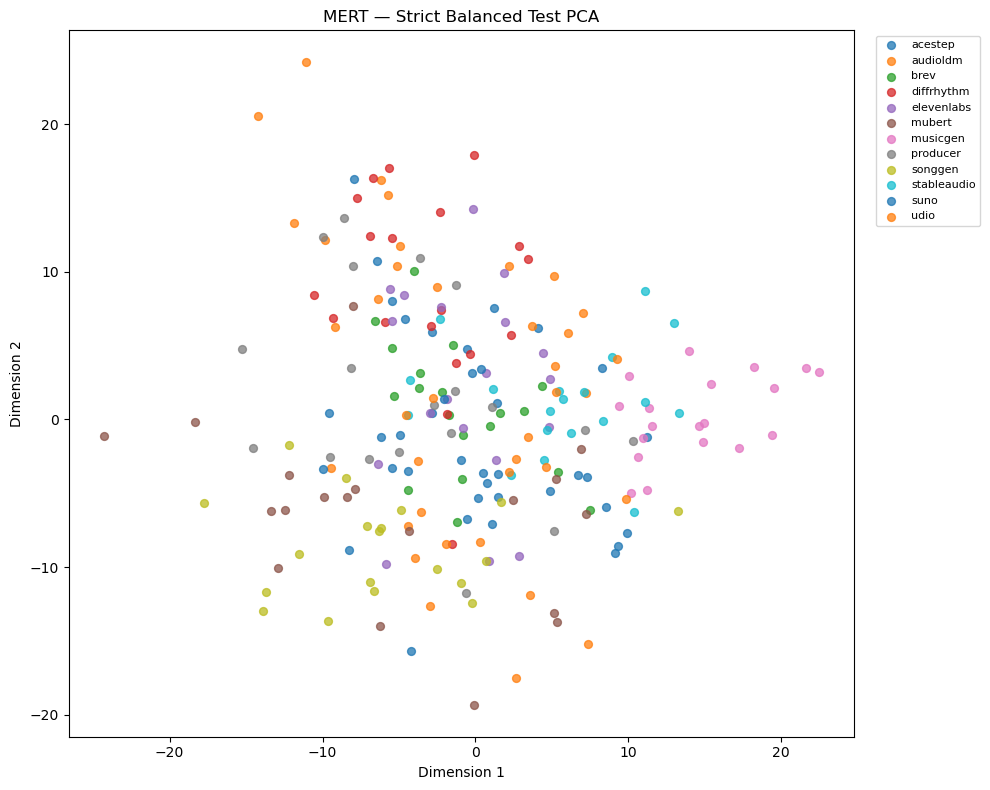

In [9]:


def plot_2d(coords, labels, title, save_path):
    fig, ax = plt.subplots(figsize=(10, 8))

    classes = sorted(pd.Series(labels).unique())

    for cls in classes:
        mask = np.asarray(labels) == cls

        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            label=cls,
            alpha=0.75,
            s=32,
        )

    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.set_title(title)

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8,
    )

    fig.tight_layout()
    fig.savefig(
        save_path,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()


for name in ["Handcrafted", "MERT"]:
    r = pca_results[name]

    plot_2d(
        r["coords"],
        r["test"]["generator"],
        f"{name} — Strict Balanced Test PCA",
        RESULT_DIR / f"pca_{name.lower()}_strict_test.png",
    )

## 7. UMAP — Train fit / Test transform

In [10]:

umap_results = {}

for name in ["Handcrafted", "MERT"]:
    train, test, X_train, X_test = get_representation(name)

    # 특징마다 범위가 달라 표준화한다. 평균·표준편차는 Train에서만 구한다.
    scaler = StandardScaler()

    # Train의 평균·표준편차를 구하고 같은 Train 행을 변환한다.
    X_train_z = scaler.fit_transform(X_train)
    # Validation/Test에는 Train의 표준화 기준만 적용해 정보 누수를 막는다.
    X_test_z = scaler.transform(X_test)

    # UMAP은 가까운 표본의 관계를 2차원에서 살펴보기 위한 투영이다.
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=30,
        min_dist=0.15,
        metric="euclidean",
        random_state=RANDOM_STATE,
        transform_seed=RANDOM_STATE,
    )

    reducer.fit(X_train_z)
    # Train에서 맞춘 투영기를 다른 분할에 적용해 같은 좌표계로 비교한다.
    coords = reducer.transform(X_test_z)

    umap_results[name] = {
        "train": train,
        "test": test,
        "X_test_z": X_test_z,
        "coords": coords,
    }

    print(name, "UMAP test shape:", coords.shape)

print("UMAP Transform PASS: True")

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Handcrafted UMAP test shape: (228, 2)


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


MERT UMAP test shape: (228, 2)
UMAP Transform PASS: True


## 8. UMAP Test visualization

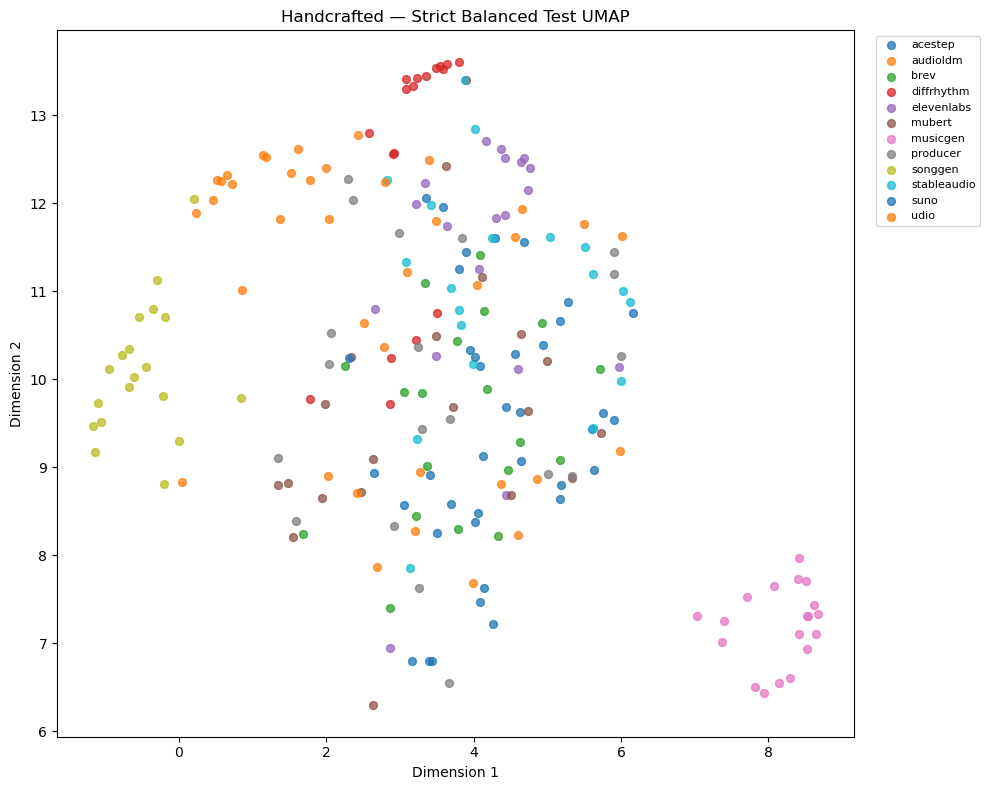

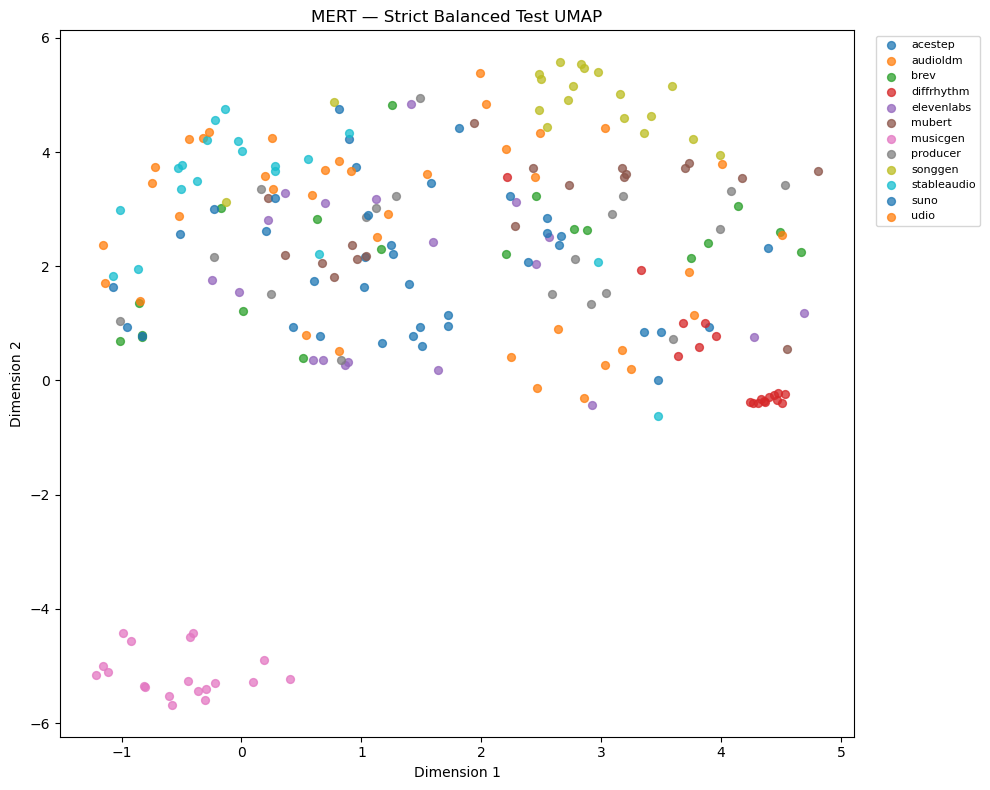

In [11]:
# UMAP Test visualization

for name in ["Handcrafted", "MERT"]:
    r = umap_results[name]

    plot_2d(
        r["coords"],
        r["test"]["generator"],
        f"{name} — Strict Balanced Test UMAP",
        RESULT_DIR / f"umap_{name.lower()}_strict_test.png",
    )

## 9. Generator silhouette score

In [12]:
# Generator silhouette score

rows = []

for name in ["Handcrafted", "MERT"]:
    labels = pca_results[name]["test"]["generator"].to_numpy()

    spaces = {
        "standardized_original": pca_results[name]["X_test_z"],
        "pca_2d": pca_results[name]["coords"],
        "umap_2d": umap_results[name]["coords"],
    }

    for space_name, X in spaces.items():
        rows.append(
            {
                "representation": name,
                "space": space_name,
                # 같은 생성기 내부 거리와 다른 생성기까지의 거리를 비교한다.
                "generator_silhouette": silhouette_score(
                    X,
                    labels,
                    metric="euclidean",
                ),
            }
        )

silhouette_df = pd.DataFrame(rows)

display(silhouette_df.round(4))

,representation,space,generator_silhouette
0,Handcrafted,standardized_original,-0.0183
1,Handcrafted,pca_2d,-0.1814
2,Handcrafted,umap_2d,0.0344
3,MERT,standardized_original,0.0164
4,MERT,pca_2d,-0.1445
5,MERT,umap_2d,0.0016


## 10. Generator vs Genre separability

In [13]:
# Generator vs Genre separability

rows = []

for name in ["Handcrafted", "MERT"]:
    test = pca_results[name]["test"]
    X = pca_results[name]["X_test_z"]

    # 같은 생성기 내부 거리와 다른 생성기까지의 거리를 비교한다.
    generator_s = silhouette_score(
        X,
        test["generator"].to_numpy(),
    )

    genre_s = silhouette_score(
        X,
        test["genre"].to_numpy(),
    )

    rows.append(
        {
            "representation": name,
            "generator_silhouette": generator_s,
            "genre_silhouette": genre_s,
            "generator_minus_genre": generator_s - genre_s,
        }
    )

generator_vs_genre = pd.DataFrame(rows)

display(generator_vs_genre.round(4))

,representation,generator_silhouette,genre_silhouette,generator_minus_genre
0,Handcrafted,-0.0183,-0.0169,-0.0014
1,MERT,0.0164,-0.0188,0.0352


## 11. 저장 / 최종 QC

In [14]:

silhouette_df.to_csv(
    RESULT_DIR / "generator_silhouette_scores.csv",
    index=False,
    encoding="utf-8-sig",
)

generator_vs_genre.to_csv(
    RESULT_DIR / "generator_vs_genre_silhouette.csv",
    index=False,
    encoding="utf-8-sig",
)

for name in ["Handcrafted", "MERT"]:
    for method, results in [
        ("pca", pca_results),
        ("umap", umap_results),
    ]:
        out_df = results[name]["test"][
            [
                "track_sample_id",
                "original_audio",
                "generator",
                "genre",
                "split",
            ]
        ].copy()

        out_df["x"] = results[name]["coords"][:, 0]
        out_df["y"] = results[name]["coords"][:, 1]

        out_df.to_csv(
            RESULT_DIR / f"{method}_{name.lower()}_strict_test.csv",
            index=False,
            encoding="utf-8-sig",
        )

qc = pd.DataFrame(
    {
        "check": [
            "strict_tracks",
            "handcrafted_dims",
            "mert_dims",
            "best_mert_layer",
            "hand_test_rows",
            "mert_test_rows",
            "silhouette_rows",
            "pca_pngs",
            "umap_pngs",
        ],
        "value": [
            len(strict_tracks),
            len(feature_cols),
            768,
            BEST_MERT_LAYER,
            len(pca_results["Handcrafted"]["test"]),
            len(pca_results["MERT"]["test"]),
            len(silhouette_df),
            (RESULT_DIR / "pca_handcrafted_strict_test.png").exists()
            and (RESULT_DIR / "pca_mert_strict_test.png").exists(),
            (RESULT_DIR / "umap_handcrafted_strict_test.png").exists()
            and (RESULT_DIR / "umap_mert_strict_test.png").exists(),
        ],
    }
)

display(qc)

core_qc_pass = (
    len(strict_tracks) == 1428
    and len(feature_cols) == 266
    and BEST_MERT_LAYER == 10
    and len(pca_results["Handcrafted"]["test"]) == 228
    and len(pca_results["MERT"]["test"]) == 228
    and len(silhouette_df) == 6
)

print("===== FINAL RESULT =====")
print(
    "Generator Fingerprint Visualization Core QC PASS:",
    core_qc_pass,
)

,check,value
0,strict_tracks,1428
1,handcrafted_dims,266
2,mert_dims,768
3,best_mert_layer,10
4,hand_test_rows,228
5,mert_test_rows,228
6,silhouette_rows,6
7,pca_pngs,True
8,umap_pngs,True


===== FINAL RESULT =====
Generator Fingerprint Visualization Core QC PASS: True


## 버전 안내

이 노트북은 초기 시각화 실험본이다. 최종 실행 및 해석은 `20_generator_fingerprint_pca_umap_v2.ipynb`를 기준으로 한다.

v2에서는 12개 generator의 고정 색상표, Train-fit/Test-transform 원칙, 저장된 PCA/UMAP 그림과 silhouette 결과를 최종 반영했다.